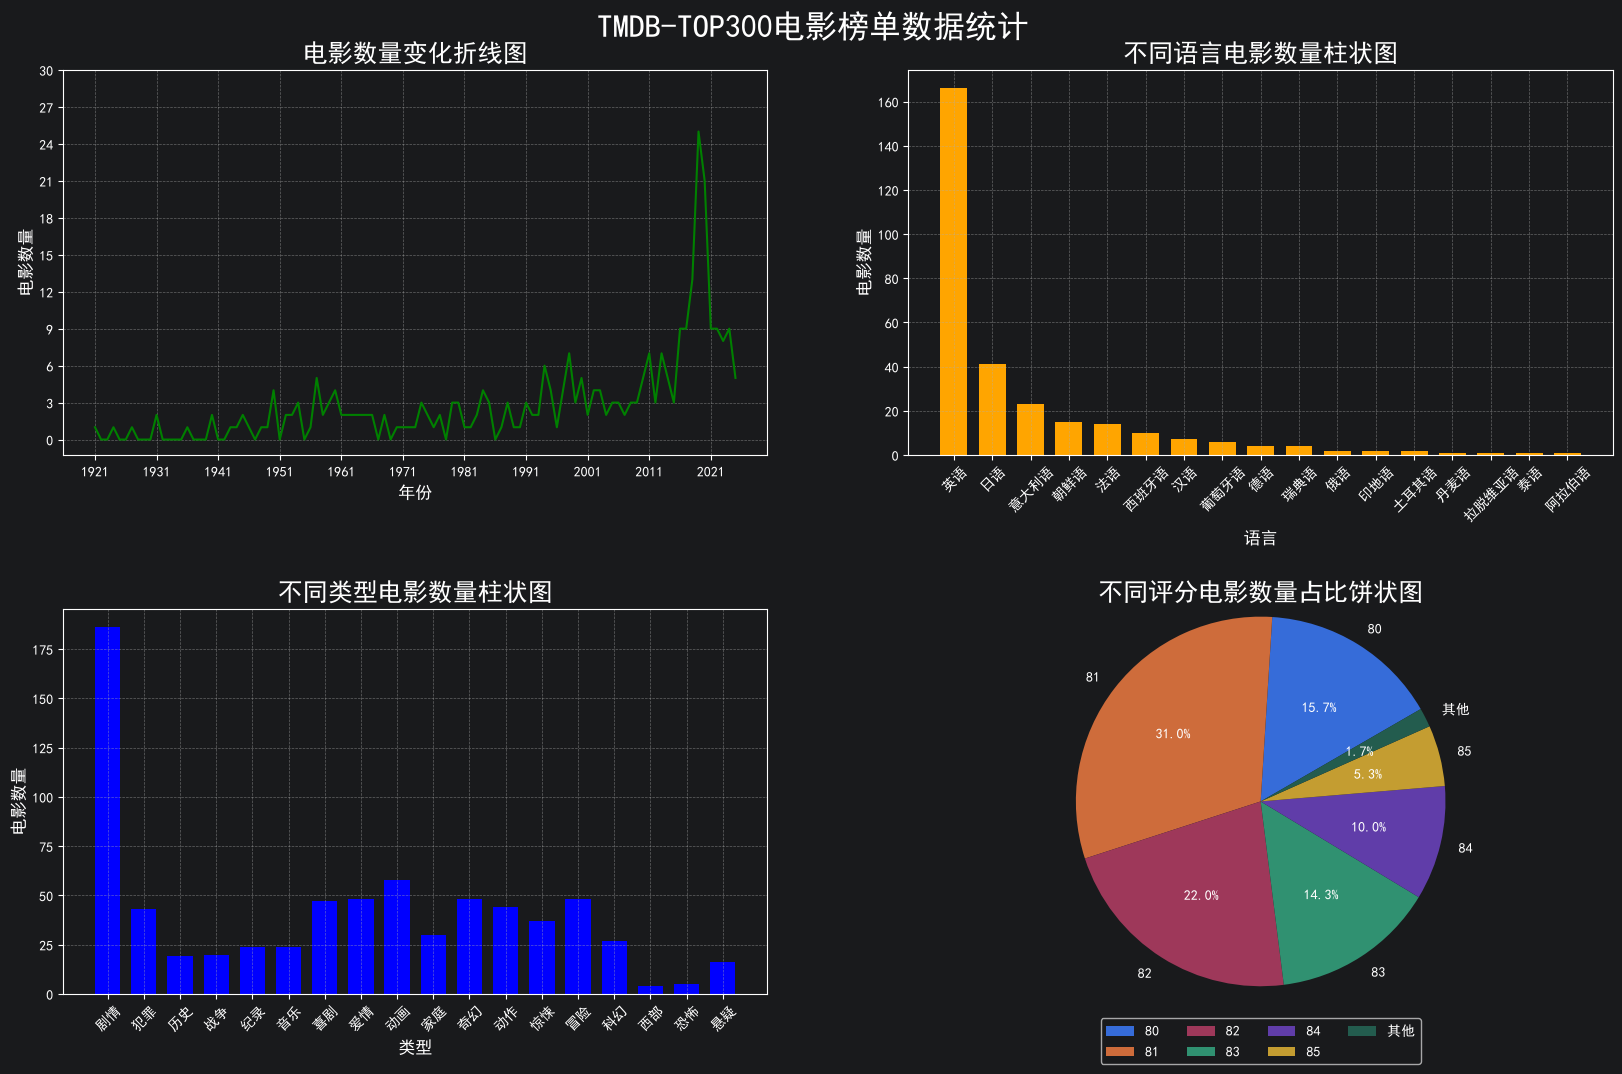

In [11]:
from pydeck.data_utils.viewport_helpers import bbox_to_zoom_level

#统计每一年上映电影数量的变化
"""
1准备工作：导入依赖库，配置运行时参数，创建子图完成基本布局，加载数据
2统计每一年电影的数量变化（折线图）
3对比不同语言电影数量（柱状图）
4对比不同类型电影数量（柱状图）
5对比各个电影评分比例（饼状图）
"""

#准备工作
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt

#展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

#创建子图
fig,axes = plt.subplots(nrows=2,ncols=2,figsize=(20, 12),dpi=100)
#大标题
fig.suptitle('TMDB-TOP300电影榜单数据统计',fontsize=23,x=0.5,y=0.93)
fig.subplots_adjust(wspace=0.2,hspace=0.4)#空值表间距 列间距，行间距
#获取子图
axes1:Axes = axes[0][0]
axes2:Axes = axes[0][1]
axes3:Axes = axes[1][0]
axes4:Axes = axes[1][1]

#加载数据
#int64 :整型数字（不支持空值）
#Int64 :整型数字（支持空值）
#float64 :浮点型数字（支持空值）
data = pd.read_csv('data/movies.csv',usecols=['电影名','年份','上映时间','类型','时长','评分','语言'],dtype={'年份':'Int64'})
data

#1统计每一年电影的数量变化（折线图）
#1.1缺失值，异常值处理
data.isnull().sum()#判断每个单元格是不是空值
data['年份'] = data['年份'].fillna(data['上映时间'].str[0:4])
data

#1.2分组统计
year_count = data.groupby('年份')['年份'].count()
#1.3组装数据
#x轴数据
min_year = year_count.index.min()
max_year = year_count.index.max()
x = [i for i in range(min_year,max_year+1)]
#y轴数据
y = [int(year_count.get(i,0)) for i in x]
#绘制折线图
axes1.plot(x,y,color='green')#折线颜色
axes1.set_title('电影数量变化折线图',fontsize=18)#标题
axes1.set_xlabel('年份',fontsize=12)#x轴标签
axes1.set_ylabel('电影数量',fontsize=12)#y轴标签
axes1.set_xticks(x[::10])#x轴刻度展示
axes1.set_yticks([i for i in range(0,31,3)])#y轴刻度标签
axes1.grid(linestyle='--',alpha=0.5)#添加网格

#2统计不同语言对应电影数量
#2.1分组统计:获取不同语言对应的电影数量
language_count = data.groupby('语言')['语言'].count().sort_values(ascending=False)
x_language = language_count.index.tolist() #x轴数据（语言列）
y_language_count = language_count.values.tolist()
#2.2绘制柱状图
axes2.bar(x_language,y_language_count,color='orange',width=0.7)#绘制柱状图
axes2.set_title('不同语言电影数量柱状图',fontsize=18)
axes2.set_xlabel('语言',fontsize=12)
axes2.set_ylabel('电影数量',fontsize=12)
axes2.grid(linestyle='--',alpha=0.5)
axes2.tick_params(axis='x',rotation=45)#哪个轴，旋转多少度

#3统计对比不同类型电影数量
#3.1分组统计:获取不同类型对应的电影数量（核心是获取数据）
type_count = {}#{'剧情':3,'犯罪':3}
for types in data['类型'].str.split(','):
    for type in types:
        if type in type_count:
            type_count[type] += 1
        else:
            type_count[type] = 1

x_types = list(type_count.keys())
y_types_count = list(type_count.values())
#3.2绘制柱状图
axes3.bar(x_types,y_types_count,color='b',width=0.7)
axes3.set_title('不同类型电影数量柱状图',fontsize=18)
axes3.set_xlabel('类型',fontsize=12)
axes3.set_ylabel('电影数量',fontsize=12)
axes3.grid(linestyle='--',alpha=0.5)
axes3.tick_params(axis='x',rotation=45)

#4不同评分电影数量占比（饼状图）
#4.1分组统计:获取不同评分对应的电影数量（核心是获取数据）
score_count = data.groupby('评分')['评分'].count()

#合并小数据(占比小于2%)为其他
total = score_count.sum()
large_scores = score_count.loc[score_count/total>=0.02]#大数据
small_scores = score_count.loc[score_count/total<0.02]#小数据
if small_scores.shape[0]>0:
    large_scores['其他'] = small_scores.sum()

scores = large_scores.index.tolist()
scores_values = large_scores.values.tolist()
# #4.2绘制饼状图
axes4.pie(scores_values,labels=scores,autopct='%.1f%%',startangle=30,radius=1.2)#startangle旋转角度 radius半径
axes4.set_title('不同评分电影数量占比饼状图',fontsize=18)
axes4.legend(loc='lower center',ncol=4,bbox_to_anchor=(0.5,-0.2))

#5保存图片
plt.savefig('data/TMDB-TOP300.png',dpi=100)

plt.show()#显示画布
